In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

#------ NATURAL UNIT CONVERSIONS-----------
cm_to_GeVinv, g_to_GeV, c_light = 5.07e13, 5.62e23, 3e10

#------ CONSTANTS-----------
rho_chi = 0.3 * (1 / cm_to_GeVinv**3)
R_sun = 7e10 * cm_to_GeVinv
v_max, v0 = 600e5 / c_light, 220e5 / c_light
rho_c = 150 * g_to_GeV / (cm_to_GeVinv**3)
rT = 0.1 * R_sun

#------ FUNCTION TO LOAD SOLAR MODEL-----------
def load_solar_model(filename, model_type="BP2000"):
    clean_rows = []
    
    with open(filename) as f:
        for line in f:
            if line.startswith("#"): continue
            parts = line.strip().split()
            
            try: nums = [float(x) for x in parts]
            except: continue

            if model_type == "BP2000" and len(nums) == 12: clean_rows.append(nums)
            elif model_type == "AGSS09" and len(nums) >= 35: clean_rows.append(nums)

    data = np.array(clean_rows)
    print(f"{model_type} shape =", data.shape)

    #------ COLUMN EXTRACTION-----------
    if model_type == "BP2000":
        R_frac, rho_cgs = data[:,1], data[:,3]
        XH_tab, YHe_tab = data[:,6], data[:,7]
        Z_tab = np.clip(1 - XH_tab - YHe_tab, 0.0, 1.0)
        XFe_tab, XP_tab = 0.06 * Z_tab, 5e-5 * Z_tab
    elif model_type == "AGSS09":
        R_frac, rho_cgs = data[:,1], data[:,3]
        XH_tab, YHe_tab = data[:,6], data[:,7]
        XP_tab, XFe_tab = data[:,21], data[:,32]

    #------ RADIUS-----------
    r_tab = R_frac * R_sun

    #------ DENSITY-----------
    rho_tab = rho_cgs * g_to_GeV / (cm_to_GeVinv**3)

    #------ MASS PROFILE-----------
    r_cm = r_tab / cm_to_GeVinv

    def compute_M_of_r(r_array, rho_array):
        M = np.zeros_like(r_array)
        for i in range(1, len(r_array)):
            dr = r_array[i] - r_array[i-1]
            rho_avg = 0.5 * (rho_array[i] + rho_array[i-1])
            r_avg = 0.5 * (r_array[i] + r_array[i-1])
            shell = 4 * np.pi * rho_avg * r_avg**2 * dr
            M[i] = M[i-1] + shell
        return M

    M_tab_cgs = compute_M_of_r(r_cm, rho_cgs)

    #------ ESCAPE VELOCITY-----------
    G_cgs = 6.674e-8
    vesc_tab = np.sqrt(2 * G_cgs * M_tab_cgs / np.maximum(r_cm, 1e-10))
    vesc_tab[0] = vesc_tab[1]
    vesc_tab = vesc_tab / c_light

    return {
        "r_tab": r_tab, "rho_tab": rho_tab, "vesc_tab": vesc_tab,
        "XH_tab": XH_tab, "XFe_tab": XFe_tab, "XP_tab": XP_tab
    }

#------ LOAD BOTH SOLAR MODELS-----------
bp2000 = load_solar_model("bp2000_standard.txt", "BP2000")
agss09 = load_solar_model("AGSS09_standard.txt", "AGSS09")

#------ SOLAR MODEL SELECTOR-----------
solar_models = {"BP2000": bp2000, "AGSS09": agss09}

def set_solar_model(model_name):
    global vesc_interp, rho_interp, XH_interp, XFe_interp, XP_interp
    model = solar_models[model_name]

    vesc_interp = lambda r: np.interp(r, model["r_tab"], model["vesc_tab"])
    rho_interp = lambda r: np.interp(r, model["r_tab"], model["rho_tab"])
    XH_interp = lambda r: np.interp(r, model["r_tab"], model["XH_tab"])
    XFe_interp = lambda r: np.interp(r, model["r_tab"], model["XFe_tab"])
    XP_interp = lambda r: np.interp(r, model["r_tab"], model["XP_tab"])

    print(f"Using solar model: {model_name}")

BP2000 shape = (876, 12)
AGSS09 shape = (1968, 35)


In [4]:
set_solar_model("BP2000")

Using solar model: BP2000


In [9]:
c4_0, c4_1 = 0.0, 0.0
c8_0, c8_1 = 0.0, 0.0
c15_0, c15_1 = 0.0, 0.0

#------ VELOCITY DISTRIBUTION-----------
v_sun = 232e5 / c_light  # in natural units

def f_raw(u):
    return (u/(np.sqrt(np.pi)*v0*v_sun)) * (np.exp(-(u - v_sun)**2 / v0**2) - np.exp(-(u + v_sun)**2 / v0**2))

u_norm = np.linspace(0, v_max, 4000)
norm = np.trapz(f_raw(u_norm), u_norm)

def f(u):
    return f_raw(u)/norm

#------ ESCAPE VELOCITY-----------
def w(u, r):
    return np.sqrt(u**2 + vesc_interp(r)**2)

#------ REDUCED MASS-----------
def mu(mchi, mT):
    return (mchi*mT)/(mchi + mT)

#------ ENERGY LIMITS-----------
def Emax(mchi, mT, u, r):
    muT = mu(mchi, mT)
    return 2*(muT**2)*(w(u,r)**2)/mT

def Emin(mchi, u, r):
    return 0.5*mchi*(w(u,r)**2 - vesc_interp(r)**2)

#------ NUMBER DENSITY-----------
def nT(r, element):
    rho = float(rho_interp(r))
    if rho <= 0: return 0.0

    if element == "H":
        X, mT = float(XH_interp(r)), 1.0 * 0.931 # convert amu → GeV
    elif element == "Fe":
        X, mT = float(XFe_interp(r)), 56.0 * 0.931 # convert amu → GeV
    elif element == "P":
        X, mT = float(XP_interp(r)), 31.0 * 0.931 # convert amu → GeV

    return (X * rho) / mT
    
#------ Dimensionless parameter b-----------
def b_param(A):
    return np.sqrt(41.467 / (45*A**(-1/3) - 25*A**(-2/3)))

#------ NUCLEAR RESPONSE-----------
def W_total(q, element, op):
    # ---------- HYDROGEN ----------
    if element == "H":
        WM, WS1, WS2 = 0.0397887, 0.0795775, 0.0397887

        if op == "O4":
            return {
                "Sigma_p": {"00": WS1, "11": WS1, "10": WS1, "01": WS1},
                "Sigma_pp": {"00": WS2, "11": WS2, "10": WS2, "01": WS2}
            }
        elif op == "O8":
            return {"00":WM, "11":WM, "10":WM, "01":WM}
        elif op == "O15":
            # Hydrogen contributes through Σ′
            return {"Sigma_p": {"00": WS1, "11": WS1, "10": WS1, "01": WS1}}

    # ---------- IRON ----------
    elif element == "Fe":
        A, b = 56, b_param(56)
        y = (q * b / 2)**2
        expf = np.exp(-2*y)

        # ---- M ----
        WM00 = expf*(62.3888 -160.428*y +152.644*y**2 -67.2779*y**3 +14.478*y**4 -1.43665*y**5 +0.0525291*y**6)
        WM11 = expf*(0.318309 -1.27323*y +1.99188*y**2 -1.54562*y**3 +0.622264*y**4 -0.122277*y**5 +0.00921525*y**6)
        WM10 = expf*(-4.45633 +14.6422*y -18.2579*y**2 +10.8919*y**3 -3.2296*y**4 +0.446836*y**5 -0.0220016*y**6)
        WM01 = WM10

        # ---- Φ'' ----
        Wphi00 = expf*(4.22872 -6.76595*y +3.79067*y**2 -0.867433*y**3 +0.069506*y**4)
        Wphi11 = expf*(0.143378 -0.229404*y +0.144606*y**2 -0.0422756*y**3 +0.00486921*y**4)
        Wphi10 = expf*(-0.778655 +1.24585*y -0.741661*y**2 +0.194658*y**3 -0.0183967*y**4)
        Wphi01 = Wphi10

        if op == "O4":
            return {"00":0, "11":0, "10":0, "01":0}
        elif op == "O8":
            return {"00":WM00, "11":WM11, "10":WM10, "01":WM01}
        elif op == "O15":
            return {"Phi_pp": {"00": Wphi00, "11": Wphi11, "10": Wphi10, "01": Wphi01}}

    # ---------- PHOSPHORUS ----------
    elif element == "P":
        A, b = 31, b_param(31)
        y = (q * b / 2)**2
        expf = np.exp(-2*y)

        WM00, WM11 = (A**2) * expf, expf      
        # include interference 
        WM10 = WM01 = A * expf

        if op == "O4":
            return {"00":0, "11":0, "10":0, "01":0}
        elif op == "O8":
            return {"00":WM00, "11":WM11, "10":WM10, "01":WM01}
        elif op == "O15":
            return {"Phi_pp": {"00":0, "11":0, "10":0, "01":0}}

    return {"00":0, "11":0, "10":0, "01":0}

#------ WIMP RESPONSE-----------
def R_total(v, q, op, mchi, mT, c0, c1):
    muT = mu(mchi, mT)
    vT2 = max(v**2 - q**2/(4*muT**2), 0.0)
    mN = 0.939
    q2 = q**2 / mN**2

    if op == "O4":
        factor = 1/16.0
        return {"00": factor * c0*c0, "11": factor * c1*c1, "01": factor * c0*c1, "10": factor * c1*c0}
    elif op == "O8":
        factor = (1/4.0) * vT2
        return {"00": factor * c0*c0, "11": factor * c1*c1, "01": factor * c0*c1, "10": factor * c1*c0}
    elif op == "O15":
        factor_phi = (1/16.0) * ((q2)**2)
        factor_sigma = (1/16.0) * ((q2)**2) * (vT2/2.0)   # Σ′ piece
        return {
            "Phi_pp": {"00": factor_phi * c0*c0, "11": factor_phi * c1*c1, "01": factor_phi * c0*c1, "10": factor_phi * c1*c0}, 
            "Sigma_p": {"00": factor_sigma * c0*c0, "11": factor_sigma * c1*c1, "01": factor_sigma * c0*c1, "10": factor_sigma * c1*c0}
        }
        
    return {"00":0, "11":0, "01":0, "10":0}
    
#------ CROSS SECTION-----------
def dsdER(mchi, mT, ER, u, r, op, element, c0, c1):
    v = w(u, r)
    if v**2 < 1e-12: return 0.0

    q = np.sqrt(2*mT*ER)
    JT = 0.5 if element in ["H", "P"] else 0.0

    W = W_total(q, element, op)
    R = R_total(v, q, op, mchi, mT, c0, c1)

    # ---------------- O4 ----------------
    if op == "O4":
        if element != "H": return 0.0
        total = sum(R[k] * (W["Sigma_p"][k] + W["Sigma_pp"][k]) for k in ["00", "11", "01", "10"])

    # ---------------- O8 ----------------
    elif op == "O8":
        total = sum(R[k] * W[k] for k in ["00", "11", "01", "10"])

    # ---------------- O15 ----------------
    elif op == "O15":
        if element == "Fe":
            total = sum(R["Phi_pp"][k] * W["Phi_pp"][k] for k in ["00", "11", "01", "10"])
        elif element == "H":
            total = sum(R["Sigma_p"][k] * W["Sigma_p"][k] for k in ["00", "11", "01", "10"])
        else:
            return 0.0
    else:
        return 0.0

    return (2 * mT * total) / ((2*JT + 1) * v**2)

#------ CAPTURE-----------
def capture_element(mchi, mT, op, element, c0, c1):
    r_vals = np.logspace(np.log10(1e-5*R_sun), np.log10(R_sun), 120)
    u_vals = np.logspace(np.log10(1e-5), np.log10(v_max), 120)
    integrand_r = []

    for r in r_vals:
        integrand_u = []
        for u in u_vals:
            if u <= 1e-8:
                integrand_u.append(0.0)
                continue

            v_rel = w(u, r)
            Emin_val = max(Emin(mchi, u, r), 0.0)
            Emax_val = Emax(mchi, mT, u, r)

            if Emax_val <= Emin_val:
                integrand_u.append(0.0)
                continue

            ER_vals = np.logspace(np.log10(Emin_val + 1e-20), np.log10(Emax_val), 150)
            ds_vals = [dsdER(mchi, mT, ER, u, r, op, element, c0, c1) for ER in ER_vals]
            ER_int = np.trapz(ds_vals, ER_vals)
            
            # CORRECT CATENA FACTOR
            val = ((f(u)/u) * (v_rel**2) * (rho_chi/mchi) * nT(r, element) * ER_int)
            integrand_u.append(val)

        integral_u = np.trapz(integrand_u, u_vals)
        integrand_r.append(integral_u * 4*np.pi*r**2) # volume element

    return np.trapz(integrand_r, r_vals)
    
#------ TOTAL-----------
def capture_by_element(mchi, op, c0, c1):
    mH, mFe, mP = 0.931, 56.0 * 0.931, 31.0 * 0.931
    CH = capture_element(mchi, mH, op, "H", c0, c1)
    CFe = capture_element(mchi, mFe, op, "Fe", c0, c1)
    CP = capture_element(mchi, mP, op, "P", c0, c1)
    return CH, CFe, CP, CH + CFe + CP

def capture_total(mchi, op, c0, c1):
    CH, CFe, CP, Ctot = capture_by_element(mchi, op, c0, c1)
    return Ctot
    
#------ COMPUTE ONCE AND SAVE-----------
mchi_vals = np.logspace(1,5,15)
GeV_to_s = 1.52e24
m_v = 246.2
c_ref = 1e-3/(m_v**2)

masses = {"H": 0.931, "Fe": 56.0 * 0.931, "P": 31.0 * 0.931}
results = {}

for op in ["O4","O8","O15"]:
    results[op] = {}
    for case in ["isoscalar","isovector"]:
        print(f"{op} : {case}")
        CH_list, CFe_list, CP_list, Ctot_list = [], [], [], []

        for m in mchi_vals:
            c0, c1 = (c_ref, 0.0) if case == "isoscalar" else (0.0, c_ref)

            CH  = capture_element(m, masses["H"], op, "H", c0, c1)
            CFe = capture_element(m, masses["Fe"], op, "Fe", c0, c1)
            CP  = capture_element(m, masses["P"], op, "P", c0, c1)

            CH_list.append(CH*GeV_to_s)
            CFe_list.append(CFe*GeV_to_s)
            CP_list.append(CP*GeV_to_s)
            Ctot_list.append((CH+CFe+CP)*GeV_to_s)

        results[op][case] = {
            "mchi" : mchi_vals,
            "H" : CH_list,
            "Fe" : CFe_list,
            "P" : CP_list,
            "Total" : Ctot_list
        }

np.save("capture_results_BP2000.npy", results, allow_pickle=True)
print("Saved capture_results_BP2000.npy")

O4 : isoscalar
O4 : isovector
O8 : isoscalar
O8 : isovector
O15 : isoscalar
O15 : isovector
Saved capture_results_BP2000.npy


In [10]:
set_solar_model("AGSS09")

Using solar model: AGSS09


In [11]:
#------ COMPUTE ONCE AND SAVE (AGSS09)-----------
results = {}

for op in ["O4", "O8", "O15"]:
    results[op] = {}
    for case in ["isoscalar", "isovector"]:
        print(f"{op} : {case}")
        CH_list, CFe_list, CP_list, Ctot_list = [], [], [], []

        for m in mchi_vals:
            c0, c1 = (c_ref, 0.0) if case == "isoscalar" else (0.0, c_ref)

            CH  = capture_element(m, masses["H"], op, "H", c0, c1)
            CFe = capture_element(m, masses["Fe"], op, "Fe", c0, c1)
            CP  = capture_element(m, masses["P"], op, "P", c0, c1)

            CH_list.append(CH * GeV_to_s)
            CFe_list.append(CFe * GeV_to_s)
            CP_list.append(CP * GeV_to_s)
            Ctot_list.append((CH + CFe + CP) * GeV_to_s)

        results[op][case] = {
            "mchi" : mchi_vals,
            "H" : CH_list,
            "Fe" : CFe_list,
            "P" : CP_list,
            "Total" : Ctot_list
        }

np.save("capture_results_AGSS09.npy", results, allow_pickle=True)
print("Saved capture_results_AGSS09.npy")

O4 : isoscalar
O4 : isovector
O8 : isoscalar
O8 : isovector
O15 : isoscalar
O15 : isovector
Saved capture_results_AGSS09.npy


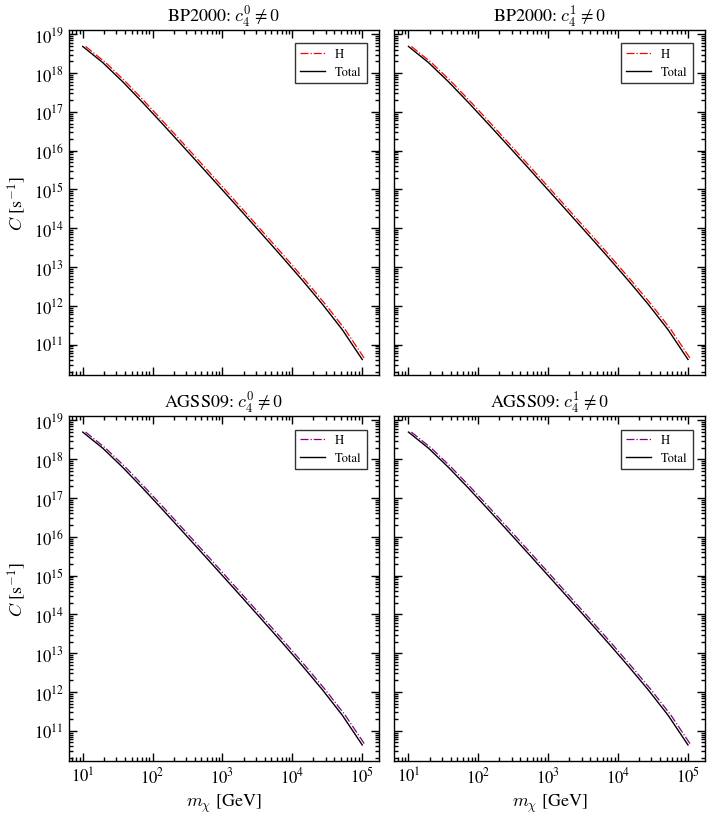

In [82]:
#------ SETUP & DATA LOAD-----------
bp = np.load("capture_results_BP2000.npy", allow_pickle=True).item()
agss = np.load("capture_results_AGSS09.npy", allow_pickle=True).item()
plt.style.use(['science', 'notebook', 'no-latex'])
op = "O4"

#------ CREATE 2 x 2 SUBPLOTS-----------
fig, axes = plt.subplots(2, 2, figsize=(7.3, 8.4), sharex=True, sharey=True)
axes = axes.flatten()

#------ PANEL INFORMATION-----------
panels = [
    (axes[0], bp, "isoscalar", "BP2000"),
    (axes[1], bp, "isovector", "BP2000"),
    (axes[2], agss, "isoscalar", "AGSS09"),
    (axes[3], agss, "isovector", "AGSS09")
]

#------ PLOT GENERATION-----------
for ax, data, case, model in panels:
    data_case = data[op][case]
    mchi = np.asarray(data_case["mchi"]) # WIMP-mass array stored in the result

    #------ HYDROGEN-----------
    if model == "BP2000":
        ax.loglog(mchi * 1.1, data_case["H"], color="red", lw=0.9, ls="-.", label="H")
    else:
        ax.loglog(mchi * 1.1, data_case["H"], color="purple", lw=0.9, ls="-.", label="H")

    #------ TOTAL CAPTURE RATE-----------
    ax.loglog(mchi, data_case["Total"], color="black", lw=1, ls="-", label="Total")

    #------ TITLE-----------
    title_str = rf"{model}: $c_{{{op[1:]}}}^0 \neq 0$" if case == "isoscalar" else rf"{model}: $c_{{{op[1:]}}}^1 \neq 0$"
    ax.set_title(title_str, fontsize=13)

    #------ X LABEL-----------
    if ax in [axes[2], axes[3]]:
        ax.set_xlabel(r"$m_\chi$ [GeV]", fontsize=13)

    #------ Y LABEL-----------
    if ax in [axes[0], axes[2]]:
        ax.set_ylabel(r"$C$ [s$^{-1}$]", fontsize=13)

    #------ LEGEND-----------
    ax.legend(loc="upper right", bbox_to_anchor=(0.98, 0.98), fontsize=9, frameon=True, edgecolor="black", fancybox=False)

    #------ TICKS-----------
    ax.tick_params(axis="both", which="major", labelsize=12)

#------ LAYOUT & SAVE-----------
plt.tight_layout()
plt.savefig(f"{op}_BP2000_AGSS09_2x2.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

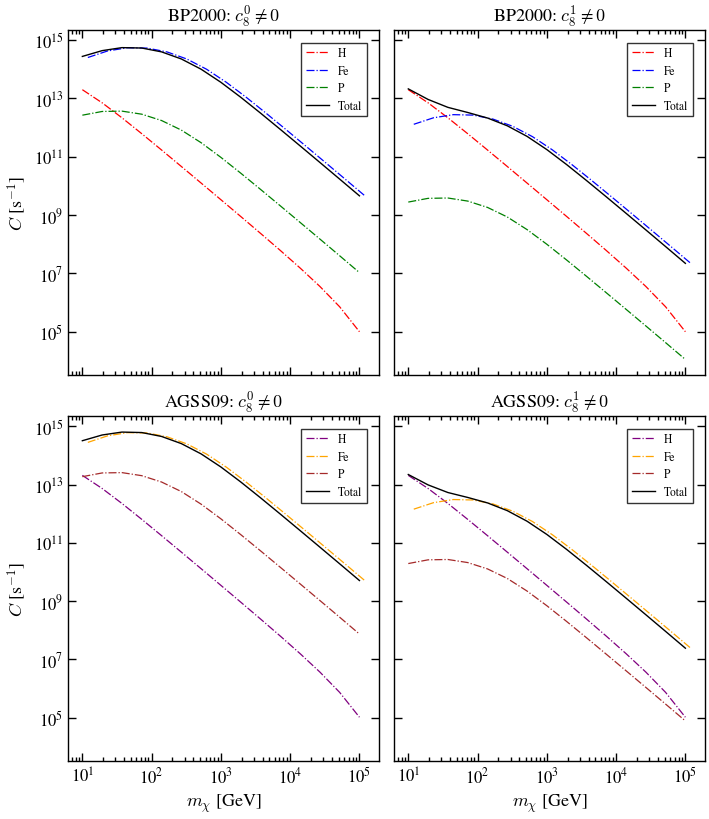

In [83]:
#------ LOAD RESULTS-----------
bp = np.load("capture_results_BP2000.npy", allow_pickle=True).item()
agss = np.load("capture_results_AGSS09.npy", allow_pickle=True).item()
plt.style.use(['science', 'notebook', 'no-latex'])
op = "O8"

#------ CREATE 2 x 2 SUBPLOTS & PANELS-----------
fig, axes = plt.subplots(2, 2, figsize=(7.3, 8.4), sharex=True, sharey=True)
axes = axes.flatten()

#------ PANEL INFORMATION-----------
panels = [
    (axes[0], bp, "isoscalar", "BP2000"),
    (axes[1], bp, "isovector", "BP2000"),
    (axes[2], agss, "isoscalar", "AGSS09"),
    (axes[3], agss, "isovector", "AGSS09")
]

#------ PLOT GENERATION-----------
for ax, data, case, model in panels:
    data_case = data[op][case]
    mchi = np.asarray(data_case["mchi"]) # WIMP mass array

    #------ HYDROGEN-----------
    if model == "BP2000":
        ax.loglog(mchi, data_case["H"], color="red", lw=0.9, ls="-.", label="H")
    else:
        ax.loglog(mchi, data_case["H"], color="purple", lw=0.9, ls="-.", label="H")

    #------ IRON-----------
    if model == "BP2000":
        ax.loglog(mchi * 1.2, data_case["Fe"], color="blue", lw=0.9, ls="-.", label="Fe")
    else:
        ax.loglog(mchi * 1.2, data_case["Fe"], color="orange", lw=0.9, ls="-.", label="Fe")

    #------ PHOSPHORUS-----------
    if model == "BP2000":
        ax.loglog(mchi, data_case["P"], color="green", lw=0.9, ls="-.", label="P")
    else:
        ax.loglog(mchi, data_case["P"], color="brown", lw=0.9, ls="-.", label="P")

    #------ TOTAL CAPTURE RATE-----------
    if model == "BP2000":
        ax.loglog(mchi, data_case["Total"], color="black", lw=1, ls="-", label="Total")
    else:
        ax.loglog(mchi, data_case["Total"], color="black", lw=1, ls="-", label="Total")

    #------ TITLE-----------
    if case == "isoscalar":
        ax.set_title(
            rf"{model}: $c_{{{op[1:]}}}^0 \neq 0$",
            fontsize=13
        )
    else:
        ax.set_title(
            rf"{model}: $c_{{{op[1:]}}}^1 \neq 0$",
            fontsize=13
        )

    #------ X LABEL-----------
    if ax in [axes[2], axes[3]]:
        ax.set_xlabel(r"$m_\chi$ [GeV]", fontsize=13)

    #------ Y LABEL-----------
    if ax in [axes[0], axes[2]]:
        ax.set_ylabel(r"$C$ [s$^{-1}$]", fontsize=13)

    #------ LEGEND-----------
    ax.legend(
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98),
        fontsize=8.3,
        frameon=True,
        edgecolor="black",
        fancybox=False
    )

    #------ TICKS-----------
    ax.tick_params(axis="both", which="major", labelsize=12)

#------ LAYOUT & SAVE-----------
plt.tight_layout()
plt.savefig(f"{op}_BP2000_AGSS09_2x2.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

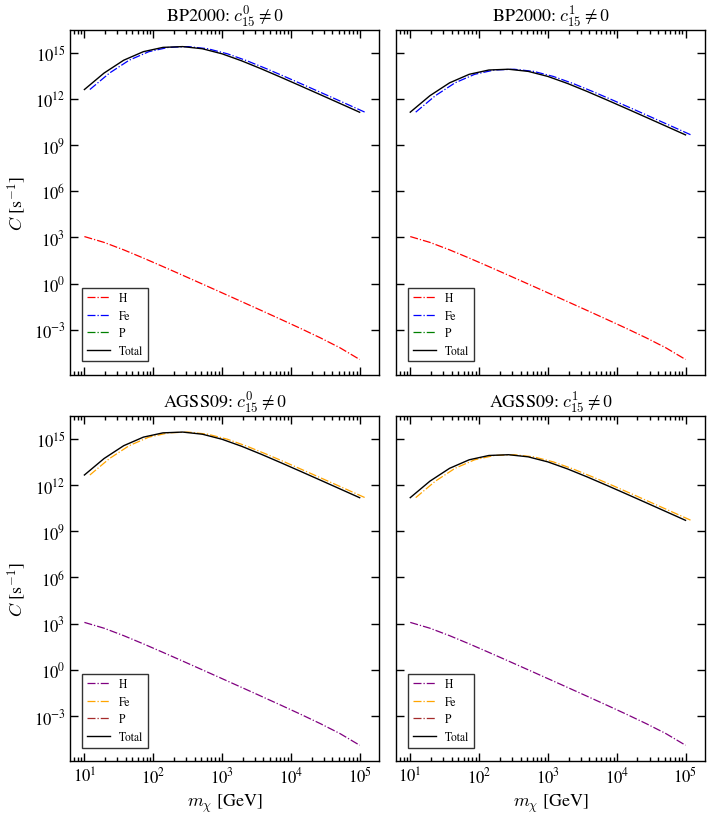

In [84]:
#------ LOAD RESULTS-----------
bp = np.load("capture_results_BP2000.npy", allow_pickle=True).item()
agss = np.load("capture_results_AGSS09.npy", allow_pickle=True).item()
plt.style.use(['science', 'notebook', 'no-latex'])
op = "O15"

#------ CREATE 2 x 2 SUBPLOTS & PANELS-----------
fig, axes = plt.subplots(2, 2, figsize=(7.3, 8.4), sharex=True, sharey=True)
axes = axes.flatten()

#------ PANEL INFORMATION-----------
panels = [
    (axes[0], bp, "isoscalar", "BP2000"),
    (axes[1], bp, "isovector", "BP2000"),
    (axes[2], agss, "isoscalar", "AGSS09"),
    (axes[3], agss, "isovector", "AGSS09")
]

#------ PLOT GENERATION-----------
for ax, data, case, model in panels:
    data_case = data[op][case]
    mchi = np.asarray(data_case["mchi"]) # WIMP mass array

    #------ HYDROGEN-----------
    if model == "BP2000":
        ax.loglog(mchi, data_case["H"], color="red", lw=0.9, ls="-.", label="H")
    else:
        ax.loglog(mchi, data_case["H"], color="purple", lw=0.9, ls="-.", label="H")

    #------ IRON-----------
    if model == "BP2000":
        ax.loglog(mchi * 1.2, data_case["Fe"], color="blue", lw=0.9, ls="-.", label="Fe")
    else:
        ax.loglog(mchi * 1.2, data_case["Fe"], color="orange", lw=0.9, ls="-.", label="Fe")

    #------ PHOSPHORUS-----------
    if model == "BP2000":
        ax.loglog(mchi, data_case["P"], color="green", lw=0.9, ls="-.", label="P")
    else:
        ax.loglog(mchi, data_case["P"], color="brown", lw=0.9, ls="-.", label="P")

    #------ TOTAL CAPTURE RATE-----------
    if model == "BP2000":
        ax.loglog(mchi, data_case["Total"], color="black", lw=1, ls="-", label="Total")
    else:
        ax.loglog(mchi, data_case["Total"], color="black", lw=1, ls="-", label="Total")

    #------ TITLE-----------
    if case == "isoscalar":
        ax.set_title(
            rf"{model}: $c_{{{op[1:]}}}^0 \neq 0$",
            fontsize=13
        )
    else:
        ax.set_title(
            rf"{model}: $c_{{{op[1:]}}}^1 \neq 0$",
            fontsize=13
        )

    #------ X LABEL-----------
    if ax in [axes[2], axes[3]]:
        ax.set_xlabel(r"$m_\chi$ [GeV]", fontsize=13)

    #------ Y LABEL-----------
    if ax in [axes[0], axes[2]]:
        ax.set_ylabel(r"$C$ [s$^{-1}$]", fontsize=13)

    #------ LEGEND-----------
    ax.legend(
        loc="upper right",
        bbox_to_anchor=(0.27, 0.27),
        fontsize=8.3,
        frameon=True,
        edgecolor="black",
        fancybox=False
    )

    #------ TICKS-----------
    ax.tick_params(axis="both", which="major", labelsize=12)

#------ LAYOUT & SAVE-----------
plt.tight_layout()
plt.savefig(f"{op}_BP2000_AGSS09_2x2.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()